### Tailing the Hedge

simular 30 días de mercado para una empresa que quiere cubrir una posición de 100,000 barriles de petróleo usando contratos de futuros (cada contrato es de 1,000 barriles).
- Cobertura Convencional (Estática): Calcula el número de contratos fijos de forma lineal desde el día uno.
- Cobertura con Tailing (Dinámica): Ajusta el número de contratos día con día usando el valor presente de la posición y la volatilidad de los rendimientos diarios.

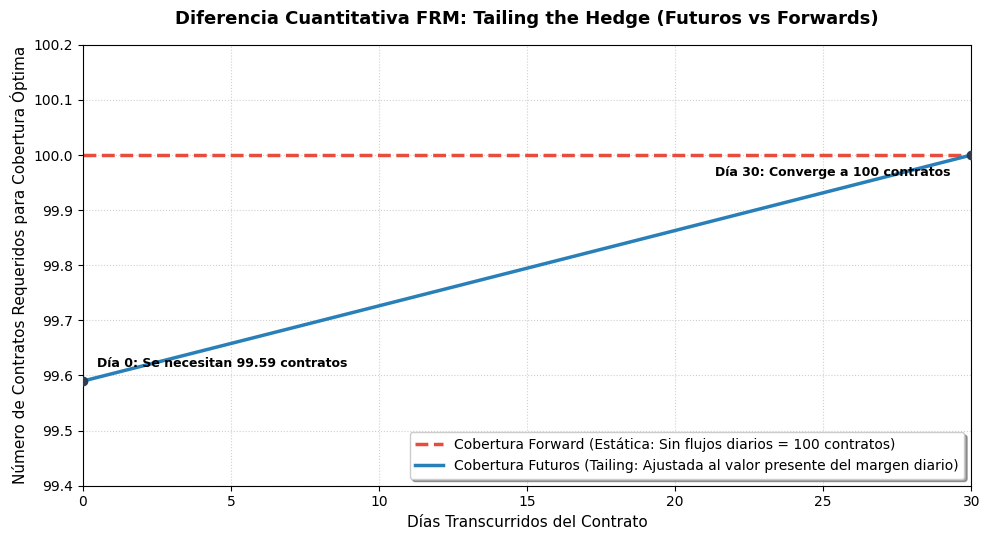

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


Q_spot = 100000        # Cantidad total de barriles a cubrir
Q_future = 1000        # Tamaño de cada contrato de futuros (1,000 barriles)
dias_totales = 30      # Plazo de la cobertura en días
tasa_anual = 0.05      # Tasa libre de riesgo (5% anual para el valor del dinero en el tiempo)

# Crear vector de días transcurridos de 0 a 30
dias_transcurridos = np.arange(dias_totales + 1)

# Tiempo restante (tau) expresado en años para cada día del contrato
tau = (dias_totales - dias_transcurridos) / 365.0

# --- 2. CÁLCULO DE LAS DOS COBERTURAS ---
# Cobertura Estática (Forwards): No se ajusta porque no hay flujos diarios. Siempre son 100 contratos.
contratos_forward = np.full(len(dias_transcurridos), Q_spot / Q_future)

# Cobertura Dinámica (Futuros - Tailing the Hedge): Se multiplica por e^(-r * tau)
# Al usar rendimientos porcentuales diarios, el analista descuenta los flujos que faltan por liquidar.
contratos_futuros = (Q_spot / Q_future) * np.exp(-tasa_anual * tau)

# --- 3. DISEÑO DE LA GRÁFICA COMPARATIVA ---
plt.figure(figsize=(10, 5.5))

# Línea para el Forward (Línea recta constante)
plt.plot(dias_transcurridos, contratos_forward, 
         label='Cobertura Forward (Estática: Sin flujos diarios = 100 contratos)', 
         color='#e74c3c', linestyle='--', linewidth=2.5)

# Línea para el Futuro (Curva ascendente)
plt.plot(dias_transcurridos, contratos_futuros, 
         label='Cobertura Futuros (Tailing: Ajustada al valor presente del margen diario)', 
         color='#2980b9', linewidth=2.5)

# Detalles y anotaciones de la gráfica para el análisis cuantitativo
plt.title('Diferencia Cuantitativa FRM: Tailing the Hedge (Futuros vs Forwards)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Días Transcurridos del Contrato', fontsize=11)
plt.ylabel('Número de Contratos Requeridos para Cobertura Óptima', fontsize=11)
plt.xlim(0, dias_totales)
plt.ylim(99.4, 100.2) # Ajuste de zoom para ver el sutil pero crítico impacto matemático
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

# Anotaciones de los puntos clave detectados en la simulación
plt.scatter([0, 30], [contratos_futuros[0], contratos_futuros[-1]], color='#2c3e50', zorder=5)
plt.annotate(f'Día 0: Se necesitan {contratos_futuros[0]:.2f} contratos', (0, contratos_futuros[0]), 
             textcoords="offset points", xytext=(10,10), ha='left', fontsize=9, fontweight='bold')
plt.annotate(f'Día 30: Converge a {contratos_futuros[-1]:.0f} contratos', (30, contratos_futuros[-1]), 
             textcoords="offset points", xytext=(-15,-15), ha='right', fontsize=9, fontweight='bold')

# Desplegar el resultado visual
plt.tight_layout()
plt.show()


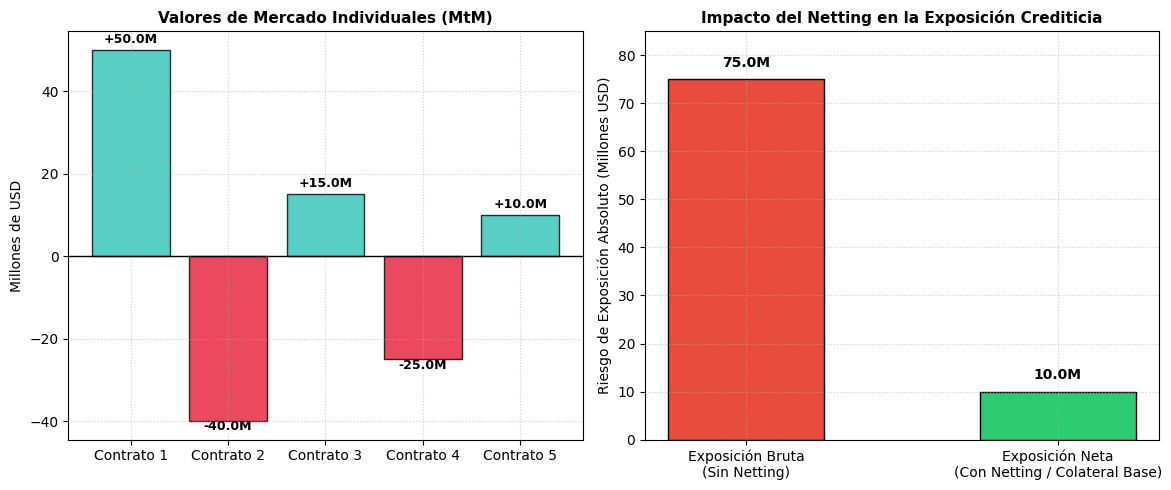

--- ANÁLISIS DE RIESGO DE CRÉDITO (FRM Part 1) ---
Suma Volumétrica Bruta negociada: 140.0M USD
Exposición al Riesgo SIN Netting: 75.0M USD (Sobreestima el riesgo)
Exposición al Riesgo CON Netting: 10.0M USD (Métrica regulatoria real)
Reducción matemática del riesgo gracias al Netting: 86.67%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DEFINICIÓN DE LA CARTERA DE DERIVADOS (Banco X con Banco Y) ---
# Valores de mercado actuales (Mark-to-Market) de 5 contratos OTC para el Banco X.
# Valores positivos: El Banco Y le debe al Banco X.
# Valores negativos: El Banco X le debe al Banco Y.
valores_contratos = np.array([50.0, -40.0, 15.0, -25.0, 10.0]) # Cifras en Millones USD
nombres_contratos = [f'Contrato {i+1}' for i in range(len(valores_contratos))]

# --- 2. CÁLCULO DE EXPOSICIÓN SIN NETTING (Enfoque Bruto Contractual) ---
# Sin netting, los contratos negativos NO compensan a los positivos. 
# El riesgo se calcula individualmente: si es positivo sumamos el riesgo, si es negativo el riesgo es 0.
exposiciones_individuales = np.maximum(valores_contratos, 0)
exposicion_bruta_total = np.sum(exposiciones_individuales)

# --- 3. CÁLCULO DE EXPOSICIÓN CON NETTING (Enfoque Agregado de Cartera) ---
# Con netting (legalmente respaldado por un acuerdo ISDA/CSA), sumamos algebraicamente 
# todos los contratos primero, y al resultado final le aplicamos el piso de cero.
suma_neta_cartera = np.sum(valores_contratos)
exposicion_neta_total = max(suma_neta_cartera, 0)

# El colateral que se va a pedir/entregar se calcula sobre esta exposición neta.
colateral_requerido = exposicion_neta_total 

# --- 4. VISUALIZACIÓN DEL IMPACTO EN EL RIESGO DE CRÉDITO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1: El valor de los contratos individuales en los libros
colores = ['#2ec4b6' if v > 0 else '#e71d36' for v in valores_contratos]
ax1.bar(nombres_contratos, valores_contratos, color=colores, edgecolor='black', alpha=0.8)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title('Valores de Mercado Individuales (MtM)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Millones de USD')
ax1.grid(True, linestyle=':', alpha=0.6)

# Añadir etiquetas de valor sobre las barras
for bar in ax1.patches:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (1 if yval > 0 else -3), f'{yval:+.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfica 2: Comparación del Riesgo que ve el Administrador de Riesgos
enfoques = ['Exposición Bruta\n(Sin Netting)', 'Exposición Neta\n(Con Netting / Colateral Base)']
valores_exposicion = [exposicion_bruta_total, exposicion_neta_total]

ax2.bar(enfoques, valores_exposicion, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
ax2.set_title('Impacto del Netting en la Exposición Crediticia', fontsize=11, fontweight='bold')
ax2.set_ylabel('Riesgo de Exposición Absoluto (Millones USD)')
ax2.set_ylim(0, exposicion_bruta_total + 10)
ax2.grid(True, linestyle=':', alpha=0.6)

# Añadir etiquetas de valor sobre las barras de exposición
for bar in ax2.patches:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 5. IMPRESIÓN DE MÉTRICAS CLAVE PARA EL REPASO QUANTE ---
print(f"--- ANÁLISIS DE RIESGO DE CRÉDITO (FRM Part 1) ---")
print(f"Suma Volumétrica Bruta negociada: {np.sum(np.abs(valores_contratos))}M USD")
print(f"Exposición al Riesgo SIN Netting: {exposicion_bruta_total}M USD (Sobreestima el riesgo)")
print(f"Exposición al Riesgo CON Netting: {exposicion_neta_total}M USD (Métrica regulatoria real)")
print(f"Reducción matemática del riesgo gracias al Netting: {((exposicion_bruta_total - exposicion_neta_total)/exposicion_bruta_total)*100:.2f}%")
